In [ ]:
import os
import sys

import numpy as np
import pandas as pd
import warnings

warnings.filterwarnings("ignore")
sys.path.append(os.path.abspath(os.path.join("modelling", '../..')))

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

from imblearn.over_sampling import SMOTE

In [30]:
SEED = 42
PLOT_DPI = 100

TRAIN_DATA_FILE = "../../datasets/Skoltech_Anomaly_Benchmark/preprocessed_skab_dataset_set2_test.csv"

USE_LDA = False

In [31]:
dataframe_train = pd.read_csv(TRAIN_DATA_FILE)
dataframe_train

,Accelerometer1RMS,Accelerometer2RMS,Current,Pressure,Temperature,Thermocouple,Voltage,Volume Flow RateRMS,Electrical_Resistence,Flow_Resistance,...,Engine_Temperature_pu_Power,Efficiency_Temperature_Difference_Ratio,AccelerometerRMS_Fluctuation,Temperature_Fluctuation,Thermocouple_Fluctuation,Volume Flow RateRMS_Fluctuation,Hydraulic_Power_Fluctuation,Electrical_Power_Fluctuation,description,anomaly
0,0.210323,0.262893,2.658640,1.074847,88.6217,29.3147,230.091,126.6770,86.544624,0.008485,...,0.170436,0.007359,0.000450,0.115096,0.005824,0.285160,8.584219,126.989244,No Anomaly,0.0
1,0.028297,0.042536,0.814120,0.745430,68.0318,24.2354,232.174,32.0000,285.184002,0.023295,...,0.423439,0.005650,0.000042,0.111232,0.004348,0.038412,16.180027,34.680405,No Anomaly,0.0
2,0.028185,0.041387,0.810610,1.073357,68.8750,24.7075,208.422,32.0000,257.117479,0.033542,...,0.479609,0.009025,0.000026,0.029276,0.006124,0.199256,12.170266,28.633766,No Anomaly,0.0
3,0.027955,0.042217,1.125930,1.073357,68.9973,24.7679,235.556,27.0000,209.210164,0.039754,...,0.306061,0.004844,0.000024,0.018756,0.002284,0.310260,8.450375,7.272027,Inlet Valve Malfunction,12.0
4,0.211749,0.272061,2.654510,1.402774,90.2739,27.8473,225.678,123.6680,85.016820,0.011343,...,0.177284,0.009096,0.000340,0.075920,0.004140,0.320000,21.923342,83.523038,No Anomaly,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7376,0.027119,0.039793,1.145980,1.073357,69.6155,24.9792,230.324,31.0000,200.984310,0.034624,...,0.310292,0.005538,0.000017,0.051492,0.003720,0.312968,18.169994,43.781339,Inlet Valve Malfunction,12.0
7377,0.209236,0.261347,2.532400,1.074847,88.9830,29.1743,222.902,126.0000,88.020060,0.008531,...,0.185456,0.007866,0.000314,0.162908,0.003280,0.386440,39.007200,33.850955,No Anomaly,0.0
7378,0.027496,0.039704,0.618982,1.073357,68.3109,24.4975,229.008,32.0317,369.975217,0.033509,...,0.566947,0.010855,0.000030,0.093068,0.004288,0.376272,7.216541,31.761236,No Anomaly,0.0
7379,0.243079,0.287370,2.320710,1.402774,85.5501,29.4859,250.139,127.3840,107.785548,0.011012,...,0.173380,0.010766,0.001260,0.094164,0.005896,0.459960,39.482278,107.722079,No Anomaly,0.0


In [ ]:
smote = SMOTE(random_state=SEED)
X_res_smote, y_res_smote = smote.fit_resample(dataframe_train.drop(columns=["anomaly", "description"]), dataframe_train.anomaly.values)

X_res_smote.shape, y_res_smote.shape

((73836, 28), (73836,))

In [33]:
dataframe_train_smote = pd.DataFrame(X_res_smote, columns=dataframe_train.drop(columns=["anomaly", "description"]).columns)
dataframe_train_smote["anomaly"] = y_res_smote

dataframe_train_smote

,Accelerometer1RMS,Accelerometer2RMS,Current,Pressure,Temperature,Thermocouple,Voltage,Volume Flow RateRMS,Electrical_Resistence,Flow_Resistance,...,AccelerometerRMS_pu_Pressure,Engine_Temperature_pu_Power,Efficiency_Temperature_Difference_Ratio,AccelerometerRMS_Fluctuation,Temperature_Fluctuation,Thermocouple_Fluctuation,Volume Flow RateRMS_Fluctuation,Hydraulic_Power_Fluctuation,Electrical_Power_Fluctuation,anomaly
0,0.210323,0.262893,2.658640,1.074847,88.621700,29.314700,230.091000,126.677000,86.544624,0.008485,...,0.000436,0.170436,0.007359,0.000450,0.115096,0.005824,0.285160,8.584219,126.989244,0.0
1,0.028297,0.042536,0.814120,0.745430,68.031800,24.235400,232.174000,32.000000,285.184002,0.023295,...,0.000038,0.423439,0.005650,0.000042,0.111232,0.004348,0.038412,16.180027,34.680405,0.0
2,0.028185,0.041387,0.810610,1.073357,68.875000,24.707500,208.422000,32.000000,257.117479,0.033542,...,0.000036,0.479609,0.009025,0.000026,0.029276,0.006124,0.199256,12.170266,28.633766,0.0
3,0.027955,0.042217,1.125930,1.073357,68.997300,24.767900,235.556000,27.000000,209.210164,0.039754,...,0.000044,0.306061,0.004844,0.000024,0.018756,0.002284,0.310260,8.450375,7.272027,12.0
4,0.211749,0.272061,2.654510,1.402774,90.273900,27.847300,225.678000,123.668000,85.016820,0.011343,...,0.000466,0.177284,0.009096,0.000340,0.075920,0.004140,0.320000,21.923342,83.523038,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73831,0.027886,0.040552,0.659105,1.073357,68.771900,24.276700,224.555000,29.000000,340.696854,0.037012,...,0.000039,0.546657,0.009268,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,13.0
73832,0.027444,0.039178,0.874550,1.073357,69.170110,24.114025,230.599120,28.044775,263.722274,0.038273,...,0.000038,0.403548,0.006497,0.000027,0.044364,0.005078,0.438414,10.173090,32.365782,13.0
73833,0.027507,0.038534,0.582947,1.121229,68.321039,24.179527,223.883597,30.188932,384.099283,0.037101,...,0.000035,0.616086,0.011555,0.000018,0.060470,0.003814,0.462099,9.613029,27.021158,13.0
73834,0.027886,0.040552,0.659105,1.073357,68.771900,24.276700,224.555000,29.000000,340.696854,0.037012,...,0.000039,0.546657,0.009268,0.000003,0.011400,0.001026,0.068666,0.804029,2.564688,13.0


In [34]:
columns = dataframe_train.drop(columns=["anomaly", "description"]).columns
for idx, col in enumerate(columns):
    print(f"{idx}: {col}")

0: Accelerometer1RMS
1: Accelerometer2RMS
2: Current
3: Pressure
4: Temperature
5: Thermocouple
6: Voltage
7: Volume Flow RateRMS
8: Electrical_Resistence
9: Flow_Resistance
10: Temperature_EbyF
11: AccelerometerRMS
12: Specific_Power
13: Accelerometer_Balance
14: Temperature_Difference
15: Hydraulic_Power
16: Electrical_Power
17: Actual_Efficiency
18: Vibration_Intensity_Ratio
19: AccelerometerRMS_pu_Pressure
20: Engine_Temperature_pu_Power
21: Efficiency_Temperature_Difference_Ratio
22: AccelerometerRMS_Fluctuation
23: Temperature_Fluctuation
24: Thermocouple_Fluctuation
25: Volume Flow RateRMS_Fluctuation
26: Hydraulic_Power_Fluctuation
27: Electrical_Power_Fluctuation


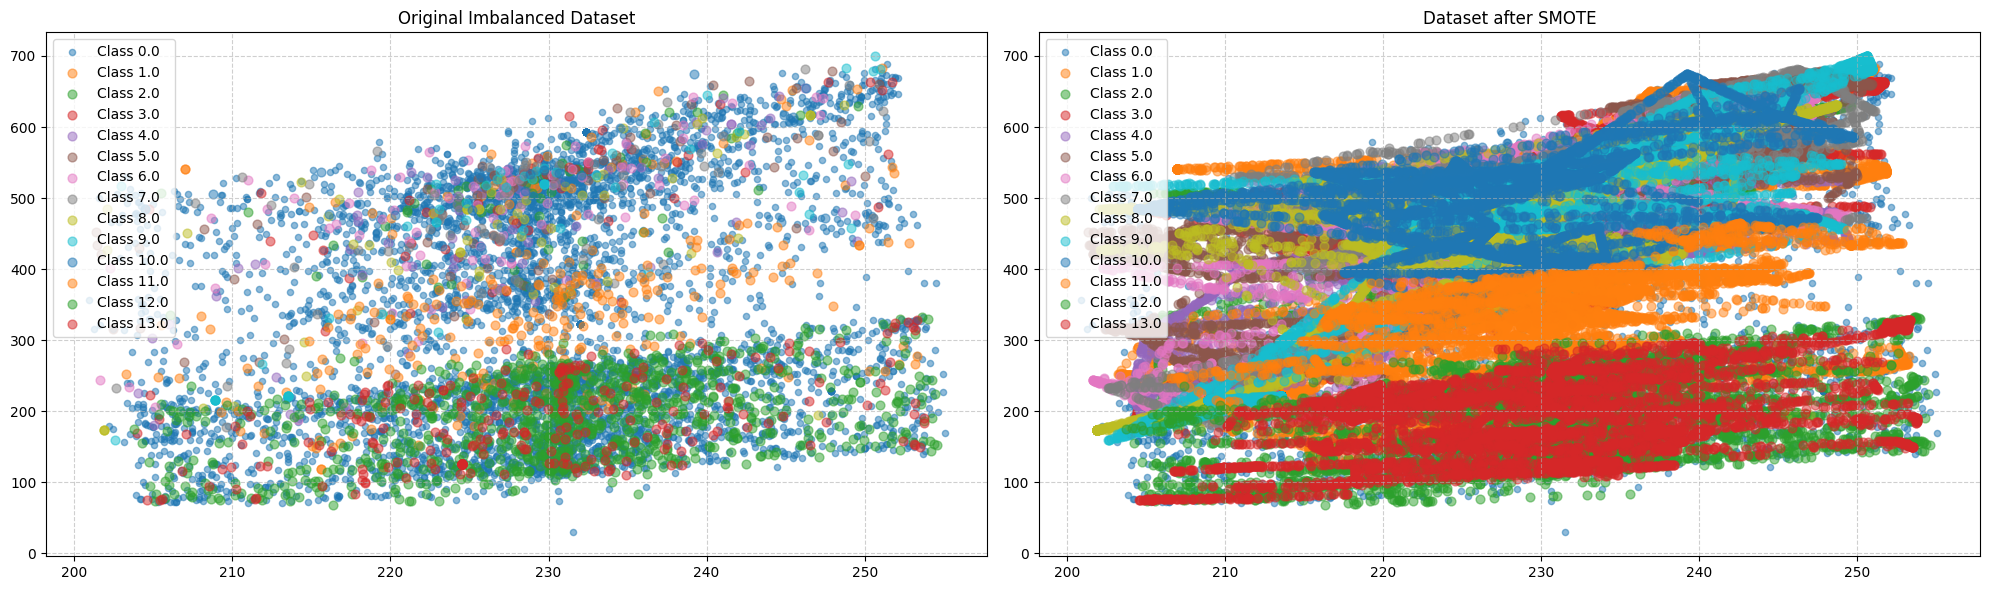

In [35]:
col1, col2 = columns[6], columns[16]

fig, axs = plt.subplots(1, 2, figsize=(20, 6), dpi=PLOT_DPI)

axs[0].set_title("Original Imbalanced Dataset")
for class_label in np.unique(dataframe_train.anomaly):
    axs[0].scatter(
                    dataframe_train[dataframe_train.anomaly == class_label][col1], 
                    dataframe_train[dataframe_train.anomaly == class_label][col2], 
                    label=f'Class {class_label}', alpha=0.5, s=20 if class_label == 0 else 40
    )
axs[0].legend()
axs[0].grid(True, linestyle='--', alpha=0.6)

axs[1].set_title("Dataset after SMOTE")
for class_label in np.unique(dataframe_train_smote.anomaly):
    axs[1].scatter(
                    dataframe_train_smote[dataframe_train_smote.anomaly == class_label][col1], 
                    dataframe_train_smote[dataframe_train_smote.anomaly == class_label][col2], 
                    label=f'Class {class_label}', alpha=0.5, s=20 if class_label == 0 else 40
    )
axs[1].legend()
axs[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()